In [1]:
# Import necessary libraries
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import pandas as pd
import numpy as np
import os
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import nltk

# Import from your custom modules
from src.feature_extraction import extract_features
from src.model import load_model, save_model

# Define paths
DATA_PATH = r'C:\Project_NLP\data\20newsgroups'
MODEL_PATH = r'C:\Project_NLP\models'

# Ensure directories exist
os.makedirs(MODEL_PATH, exist_ok=True)

print("Setup complete.")

Setup complete.


[nltk_data] Downloading package punkt to C:\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
def parse_newsgroup_files(data_path):
    """Parse the 20 Newsgroups text files into a DataFrame with document_id, text, and newsgroup."""
    documents = []
    total_messages = 0
    for newsgroup_file in os.listdir(data_path):
        if newsgroup_file.endswith('.txt'):
            file_path = os.path.join(data_path, newsgroup_file)
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                content = f.read()
                # Split into individual messages using a more robust separator
                messages = re.split(r'\n\s*\n(?=Newsgroup:)', content)
                for i, msg in enumerate(messages):
                    total_messages += 1
                    lines = msg.split('\n')
                    if len(lines) < 2:  # Relaxed condition to include messages with at least a header
                        continue
                    # Extract Newsgroup from the header
                    newsgroup_line = [line for line in lines if line.startswith('Newsgroup:')]
                    if not newsgroup_line:
                        continue
                    newsgroup = newsgroup_line[0].replace('Newsgroup: ', '').strip()
                    # Extract Document_id from the header
                    doc_id_line = [line for line in lines if line.startswith('Document_id:')]
                    if not doc_id_line:
                        continue
                    doc_id = doc_id_line[0].replace('Document_id: ', '').strip()
                    # Convert document_id to integer, handle potential non-numeric values
                    try:
                        doc_id = int(doc_id)
                    except ValueError:
                        continue  # Skip if document_id is not a valid integer
                    # Extract the message body (after headers)
                    body_start = 0
                    for j, line in enumerate(lines):
                        if line.startswith('Subject:'):
                            body_start = j + 1
                            break
                    body = ' '.join(lines[body_start:]).strip()
                    if body:
                        documents.append({'document_id': doc_id, 'text': body, 'newsgroup': newsgroup})
                    else:
                        print(f"Empty body in file {newsgroup_file}, message {i}")
    print(f"Total messages parsed: {total_messages}")
    print(f"Valid documents after parsing: {len(documents)}")
    return pd.DataFrame(documents)

# Parse documents
df = parse_newsgroup_files(DATA_PATH)

# Debug: Check the DataFrame
print("DataFrame Info:")
print(df.info())
print(f"DataFrame Shape: {df.shape}")
# Debug: Check class distribution
print("Class distribution in df:")
print(df['newsgroup'].value_counts())

Empty body in file alt.atheism.txt, message 1483
Empty body in file comp.graphics.txt, message 987
Empty body in file comp.os.ms-windows.misc.txt, message 1362
Empty body in file comp.os.ms-windows.misc.txt, message 1363
Empty body in file comp.os.ms-windows.misc.txt, message 1368
Empty body in file comp.os.ms-windows.misc.txt, message 1783
Empty body in file comp.os.ms-windows.misc.txt, message 1942
Empty body in file comp.sys.ibm.pc.hardware.txt, message 1238
Empty body in file comp.sys.ibm.pc.hardware.txt, message 1245
Empty body in file comp.sys.ibm.pc.hardware.txt, message 1462
Empty body in file comp.sys.mac.hardware.txt, message 1135
Empty body in file comp.sys.mac.hardware.txt, message 1427
Empty body in file comp.sys.mac.hardware.txt, message 1627
Empty body in file comp.sys.mac.hardware.txt, message 1754
Empty body in file comp.windows.x.txt, message 1213
Empty body in file comp.windows.x.txt, message 1830
Empty body in file misc.forsale.txt, message 977
Empty body in file mi

In [3]:
df.shape

(18796, 3)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18796 entries, 0 to 18795
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   document_id  18796 non-null  int64 
 1   text         18796 non-null  object
 2   newsgroup    18796 non-null  object
dtypes: int64(1), object(2)
memory usage: 440.7+ KB


In [5]:
df.columns

Index(['document_id', 'text', 'newsgroup'], dtype='object')

In [6]:
# Import the extract_features function
from src.feature_extraction import extract_features

# Use the extract_features function from feature_extraction.py for preprocessing
df['cleaned_text'] = df['text'].apply(lambda x: extract_features(x, vectorizer=None))

# Demonstrate stemming on a few sample texts
print("Demonstrating stemming on sample texts:")
for i, sample_text in enumerate(df['text'].head(3)):
    print(f"\nSample {i+1}:")
    cleaned_sample = extract_features(sample_text, vectorizer=None)
    print("Cleaned text:", cleaned_sample)

# Verify preprocessing
print("\nSample of cleaned text after stemming:")
print(df[['text', 'cleaned_text']].head())

Demonstrating stemming on sample texts:

Sample 1:
Cleaned text: archivenam atheismresourc altatheismarchivenam resourc lastmodifi decemb version atheist resourc address atheist organ usa freedom religion foundat darwin fish bumper sticker assort atheist paraphernalia avail freedom religion foundat us write ffrf po box madison wi telephon evolut design evolut design sell darwin fish fish symbol like one christian stick car feet word darwin written insid delux mould plastic fish postpaid us write evolut design laurel canyon north hollywood ca peopl san francisco bay area get darwin fish lynn gold tri mail figmonetcomcom net peopl go lynn directli price per fish american atheist press aap publish variou atheist book critiqu bibl list biblic contradict one book bibl handbook wp ball gw foot american atheist press pp isbn nd edit bibl contradict absurd atroc immor contain ball foot bibl contradict aap base king jame version bibl write american atheist press po box austin tx cameron road au

In [ ]:
# Step 3: Feature extraction with TF-IDF (including BoW and N-grams)
vectorizer = TfidfVectorizer(max_features=500000, ngram_range=(2, 2))  # BoW with unigrams and bigrams, TF-IDF
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['newsgroup']

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


In [24]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (15036, 500000)
Test set shape: (3760, 500000)


In [25]:
# Step 5: Train multiple models
clf_base = DecisionTreeClassifier(max_depth=3)
models = {
    'Logistic Regression': LogisticRegression(),
    #'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    #'Decision Tree': DecisionTreeClassifier(max_depth=3),
    # 'SVM': SVC(probability=True),
    #'Gradient Boosting': GradientBoostingClassifier(max_depth=3, n_estimators=200, learning_rate=0.05, random_state=42),
    #'KNN': KNeighborsClassifier(),
    #'Naive Bayes': MultinomialNB(),
    #'AdaBoost': AdaBoostClassifier(estimator=clf_base, n_estimators=200, learning_rate=0.04)
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    try:
        if len(np.unique(y_train)) < 2:
            print(f"{name} - Skipped: Training data contains only one class.")
            continue
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results[name] = (model, accuracy)
        print(f"{name} - Accuracy: {accuracy:.4f}")
    except ValueError as e:
        print(f"{name} - Error: {e}")

# Find the best model
if results:
    best_model_name, (best_model, best_accuracy) = max(results.items(), key=lambda x: x[1][1])
    print(f"\nBest Model: {best_model_name} with Accuracy: {best_accuracy:.4f}")
else:
    print("No models trained successfully due to insufficient class diversity in the training data.")

# Accuracy:0.8734,   
    

Logistic Regression - Accuracy: 0.8843

Best Model: Logistic Regression with Accuracy: 0.8843


In [26]:
from sklearn.naive_bayes import GaussianNB

# Step 5: Train multiple models
clf_base = DecisionTreeClassifier(max_depth=3)
models = {
    'Logistic Regression': LogisticRegression(max_iter=100),  # Will use dense input
    #'GaussianNB': GaussianNB(),  # Will use dense input
    #'Logistic Regression': LogisticRegression(solver='liblinear', max_iter=1000, multi_class='ovr'),  # Original sparse LR
    #'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=2, max_features='log2'),
    #'Decision Tree': DecisionTreeClassifier(max_depth=3),
    #'SVM': SVC(probability=True),
    #'Gradient Boosting': GradientBoostingClassifier(max_depth=3, n_estimators=200, learning_rate=0.05, random_state=42),
    #'KNN': KNeighborsClassifier(),
    #'Naive Bayes': MultinomialNB(),
    #'AdaBoost': AdaBoostClassifier(estimator=clf_base, n_estimators=200, learning_rate=0.04)
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    try:
        if len(np.unique(y_train)) < 2:
            print(f"{name} - Skipped: Training data contains only one class.")
            continue
        # For models requiring dense input (Logistic Regression (Dense) and GaussianNB)
        if name in ['Logistic Regression (Dense)']:
            model.fit(X_train.toarray(), y_train)  # Convert to dense array
            y_train_pred = model.predict(X_train.toarray())
            y_test_pred = model.predict(X_test.toarray())
        else:
            model.fit(X_train, y_train)  # Use sparse matrix for other models
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)
        train_score = accuracy_score(y_train, y_train_pred) * 100
        test_score = accuracy_score(y_test, y_test_pred) * 100
        results[name] = (model, test_score / 100)  # Store test accuracy as a fraction for best model selection
        print(f"{name} - Train accuracy: {train_score:.2f}%")
        print(f"{name} - Test accuracy: {test_score:.2f}%")
    except ValueError as e:
        print(f"{name} - Error: {e}")

# Find the best model based on test accuracy
if results:
    best_model_name, (best_model, best_accuracy) = max(results.items(), key=lambda x: x[1][1])
    print(f"\nBest Model: {best_model_name} with Test Accuracy: {best_accuracy*100:.2f}%")
else:
    print("No models trained successfully due to insufficient class diversity in the training data.")

# Note: Converting sparse TF-IDF matrix to dense array for Logistic Regression (Dense) and GaussianNB
# can be memory-intensive for large datasets. If memory issues arise, consider reducing max_features
# in TfidfVectorizer or using sparse-compatible models like MultinomialNB.



Logistic Regression - Train accuracy: 97.53%
Logistic Regression - Test accuracy: 88.43%

Best Model: Logistic Regression with Test Accuracy: 88.43%


In [27]:
# Save the best model, vectorizer, and label encoder using save_model from model.py
if 'best_model' in locals():
    save_model(best_model, os.path.join(MODEL_PATH, 'best_model.pkl'))
    save_model(vectorizer, os.path.join(MODEL_PATH, 'vectorizer.pkl'))
    save_model(label_encoder, os.path.join(MODEL_PATH, 'label_encoder.pkl'))
    print("Best model and components saved to 'C:\\Project_NLP\\models'")
else:
    print("No best model to save.")

Model saved to C:\Project_NLP\models\best_model.pkl
Model saved to C:\Project_NLP\models\vectorizer.pkl
Model saved to C:\Project_NLP\models\label_encoder.pkl
Best model and components saved to 'C:\Project_NLP\models'


Classification Report for Best Model:
                          precision    recall  f1-score   support

             alt.atheism       0.88      0.86      0.87       148
           comp.graphics       0.78      0.83      0.81       204
 comp.os.ms-windows.misc       0.83      0.81      0.82       193
comp.sys.ibm.pc.hardware       0.80      0.81      0.81       190
   comp.sys.mac.hardware       0.90      0.81      0.85       180
          comp.windows.x       0.83      0.88      0.86       192
            misc.forsale       0.79      0.88      0.83       199
               rec.autos       0.90      0.88      0.89       185
         rec.motorcycles       0.95      0.94      0.94       231
      rec.sport.baseball       0.95      0.97      0.96       193
        rec.sport.hockey       0.97      0.97      0.97       207
               sci.crypt       0.97      0.94      0.96       209
         sci.electronics       0.84      0.84      0.84       207
                 sci.med       0.91  

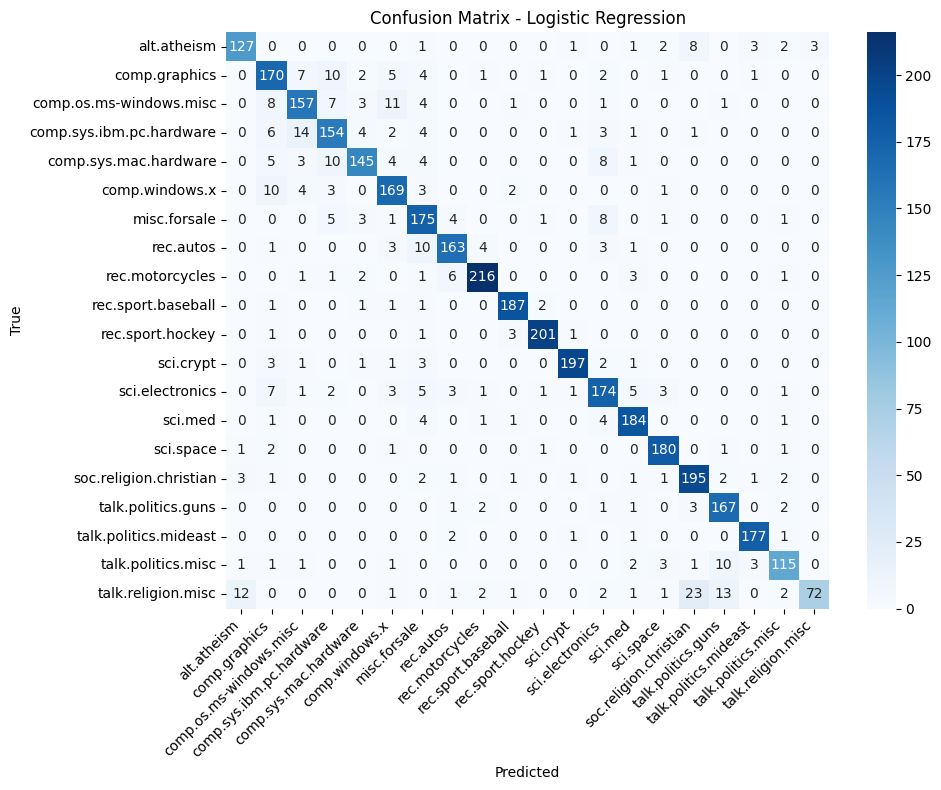

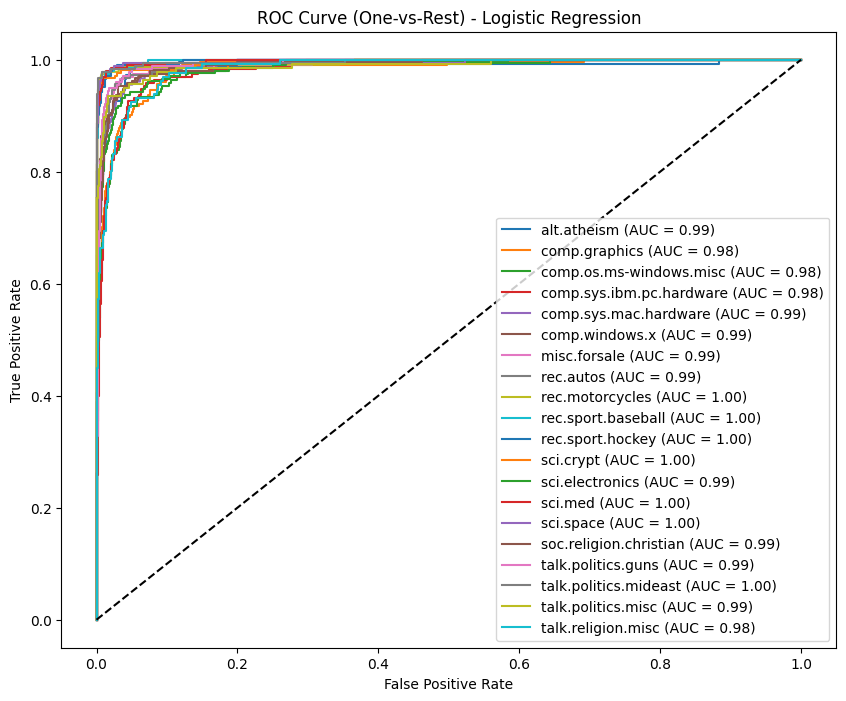

In [28]:
# Step 6: Evaluate the best model
if 'best_model' in locals():
    y_pred = best_model.predict(X_test)
    print("Classification Report for Best Model:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_PATH, 'confusion_matrix.png'))
    plt.show()

    # ROC Curve (for multi-class, we use one-vs-rest)
    if hasattr(best_model, 'predict_proba'):
        y_pred_prob = best_model.predict_proba(X_test)
        plt.figure(figsize=(10, 8))
        for i in range(len(label_encoder.classes_)):
            fpr, tpr, _ = roc_curve(y_test == i, y_pred_prob[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.title(f'ROC Curve (One-vs-Rest) - {best_model_name}')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc='lower right')
        plt.savefig(os.path.join(MODEL_PATH, 'roc_curve.png'))
        plt.show()
else:
    print("No best model to evaluate.")